In [ ]:
# A Fourier-Domain Detectability in Speckle Interferometry

**Carlos A. Guerrero**
Facultad de Ciencias Físico Matemáticas
Universidad Autónoma de Nuevo León

This notebook provides the Python implementation used to generate the figures and semi-analytical simulations presented in the manuscript:

**“A Fourier-Domain Framework for the Detectability of Binary Stars in Speckle Interferometry”**

The code is intended for reproducibility, illustration, and practical exploration of binary-star detectability in the Fourier domain.

**License:** MIT
**Version:** 1.0
**Repository:** [add GitHub link here]

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


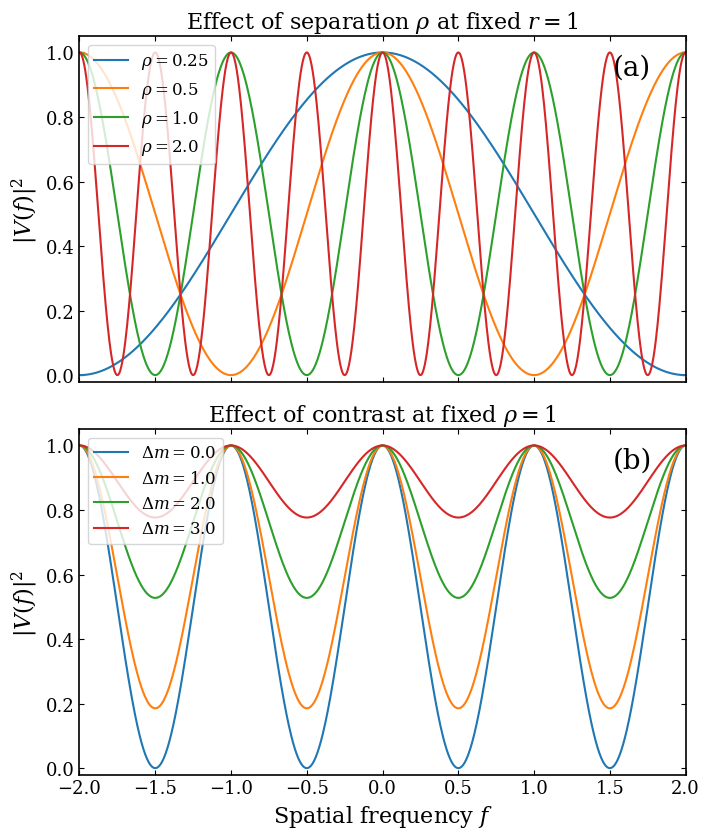

Saved to: /content/visibility_1d_configurations_vertical.pdf
File exists: True


In [20]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['axes.linewidth'] = 1.2


def flux_ratio_from_deltam(delta_m):
    return 10 ** (-0.4 * delta_m)


def visibility_squared_1d(f, rho, r, eta=1.0):
    phase = 2.0 * np.pi * f * rho
    return (1.0 + r**2 + 2.0 * r * eta * np.cos(phase)) / (1.0 + r)**2


def plot_1d_configurations_vertical(savepath):
    f = np.linspace(-8, 8, 4000)

    fig, axes = plt.subplots(2, 1, figsize=(7.2, 8.5), sharex=True, sharey=True)

    # Top panel: vary separation at fixed flux ratio
    r_fixed = 1.0
    rho_values = [0.25, 0.5, 1.0, 2.0]

    for rho in rho_values:
        vis2 = visibility_squared_1d(f, rho=rho, r=r_fixed)
        axes[0].plot(f, vis2, label=fr'$\rho={rho}$')

    axes[0].set_title(r'Effect of separation $\rho$ at fixed $r=1$', fontsize=16, family='serif')
    axes[0].set_ylabel(r'$|V(f)|^2$', fontsize=16, family='serif')
    axes[0].set_xlim(-2, 2)
    axes[0].set_ylim(-0.02, 1.05)
    axes[0].legend(loc='upper left', prop={'family': 'serif', 'size': 12})
    axes[0].annotate('(a)', xy=(0.88, 0.89), xycoords='axes fraction', fontsize=20)

    # Bottom panel: vary contrast at fixed separation
    rho_fixed = 1.0
    delta_m_values = [0.0, 1.0, 2.0, 3.0]

    for dm in delta_m_values:
        r = flux_ratio_from_deltam(dm)
        vis2 = visibility_squared_1d(f, rho=rho_fixed, r=r)
        axes[1].plot(f, vis2, label=fr'$\Delta m={dm}$')

    axes[1].set_title(r'Effect of contrast at fixed $\rho=1$', fontsize=16, family='serif')
    axes[1].set_xlabel(r'Spatial frequency $f$', fontsize=16, family='serif')
    axes[1].set_ylabel(r'$|V(f)|^2$', fontsize=16, family='serif')
    axes[1].set_xlim(-2, 2)
    axes[1].set_ylim(-0.02, 1.05)
    axes[1].legend(loc='upper left', prop={'family': 'serif', 'size': 12})
    axes[1].annotate('(b)', xy=(0.88, 0.89), xycoords='axes fraction', fontsize=20)

    for ax in axes:
        ax.tick_params(axis='both', labelsize=13, direction='in', top=True, right=True)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_family('serif')

    plt.tight_layout()
    fig.savefig(savepath, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Saved to: {savepath}')
    print(f'File exists: {os.path.exists(savepath)}')


savepath = '/content/visibility_1d_configurations_vertical.pdf'
plot_1d_configurations_vertical(savepath)

/tmp/ipykernel_5273/4203525362.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap).copy()


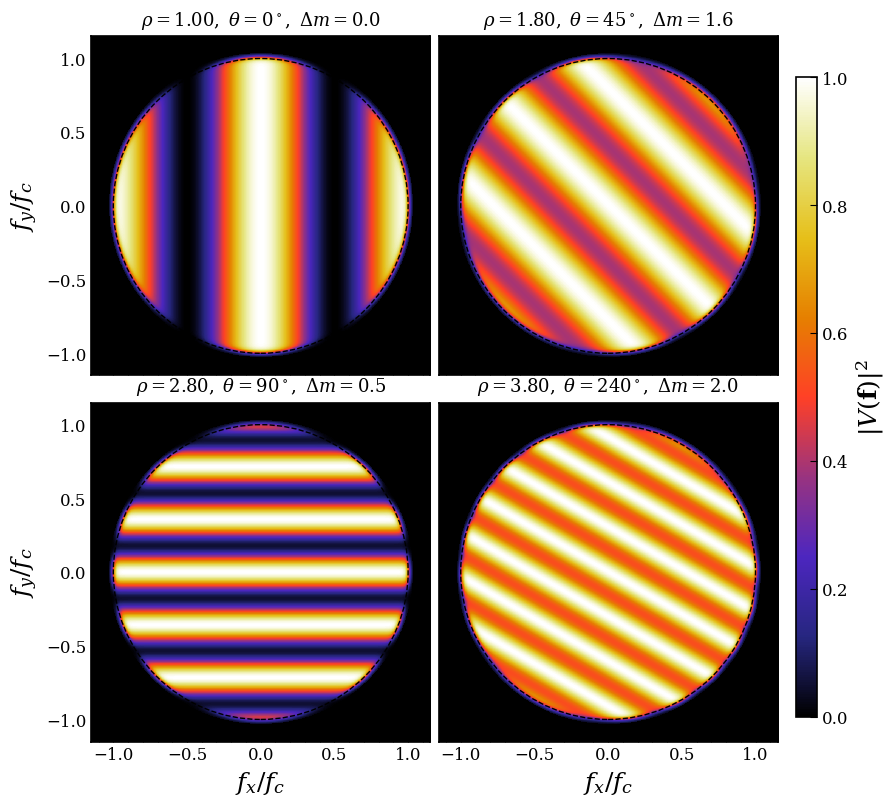

In [23]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Circle
from matplotlib.ticker import MultipleLocator

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['axes.linewidth'] = 1.2


def flux_ratio_from_deltam(delta_m):
    return 10 ** (-0.4 * delta_m)


def make_frequency_grid(fmax=1.15, n=900):
    f = np.linspace(-fmax, fmax, n)
    fx, fy = np.meshgrid(f, f)
    return fx, fy


def binary_visibility_squared_2d(fx, fy, rho, theta_deg, r, eta=1.0):
    theta = np.deg2rad(theta_deg)
    rho_x = rho * np.cos(theta)
    rho_y = rho * np.sin(theta)

    phase = 2.0 * np.pi * (fx * rho_x + fy * rho_y)
    vis2 = (1.0 + r**2 + 2.0 * r * eta * np.cos(phase)) / (1.0 + r)**2
    return vis2


def soft_circular_support(fx, fy, fc=1.0, soft_cut=0.02):
    fr = np.sqrt(fx**2 + fy**2)
    width = soft_cut * fc
    support = 0.5 * (1.0 - np.tanh((fr - fc) / width))
    return support


def generate_pws_array(rho, theta, dm, fx, fy, fc=1.0, soft_cut=0.02, eta=1.0):
    r = flux_ratio_from_deltam(dm)
    vis2 = binary_visibility_squared_2d(
        fx=fx, fy=fy,
        rho=rho, theta_deg=theta,
        r=r, eta=eta
    )
    support = soft_circular_support(fx, fy, fc=fc, soft_cut=soft_cut)
    pws = vis2 * support
    return pws


def apply_axis_style(ax, xminor=0.1, yminor=0.1):
    ax.tick_params(axis='both', which='major', direction='in',
                   bottom=True, top=True, left=True, right=True,
                   length=6, labelsize=12)
    ax.tick_params(axis='both', which='minor', direction='in',
                   bottom=True, top=True, left=True, right=True,
                   length=3)
    ax.minorticks_on()

    if xminor is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(xminor))
    if yminor is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(yminor))


def plot_binary_pws_group_preview(configs, savepath,
                                  cmap='inferno',
                                  fc=1.0,
                                  fmax=1.15,
                                  ngrid=900,
                                  soft_cut=0.02,
                                  panel_labels=None,
                                  show_inner_text=True,
                                  annotation_color='black',
                                  figsize=(8.6, 8.2),
                                  dpi=300):
    if len(configs) != 4:
        raise ValueError("configs must contain exactly four configurations.")

    if panel_labels is None:
        panel_labels = ['(a)', '(b)', '(c)', '(d)']

    # Set NaN values to black outside the support
    if isinstance(cmap, str):
        cmap = cm.get_cmap(cmap).copy()
    else:
        cmap = cmap.copy()
    cmap.set_bad('black')

    fx, fy = make_frequency_grid(fmax=fmax * fc, n=ngrid)

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)
    axes = axes.ravel()

    last_im = None

    for ax, cfg, plabel in zip(axes, configs, panel_labels):
        pws = generate_pws_array(
            rho=cfg["rho"],
            theta=cfg["theta"],
            dm=cfg["dm"],
            fx=fx,
            fy=fy,
            fc=fc,
            soft_cut=soft_cut,
            eta=cfg.get("eta", 1.0)
        )

        # Mask values outside the cutoff region
        fr = np.sqrt(fx**2 + fy**2)
        pws = pws.copy()
        pws[fr > 1.03 * fc] = np.nan

        last_im = ax.imshow(
            pws,
            origin='lower',
            extent=[-fmax, fmax, -fmax, fmax],
            cmap=cmap,
            vmin=0.0,
            vmax=1.0,
            interpolation='nearest',
            aspect='equal'
        )

        circ = Circle((0.0, 0.0), radius=1.0, fill=False,
                      edgecolor=annotation_color, linewidth=1.0,
                      linestyle='dashed')
        ax.add_patch(circ)

        ax.annotate(plabel, xy=(0.83, 0.89), xycoords='axes fraction',
                    fontsize=22, color=annotation_color)

        if show_inner_text:
            ax.set_title(
                fr'$\rho={cfg["rho"]:.2f},\ \theta={cfg["theta"]:.0f}^\circ,\ \Delta m={cfg["dm"]:.1f}$',
                fontsize=13,
                color=annotation_color,
                pad=8
            )

        apply_axis_style(ax, xminor=0.1, yminor=0.1)

        ax.set_xlim(-fmax, fmax)
        ax.set_ylim(-fmax, fmax)
        ax.set_facecolor('black')

    axes[2].set_xlabel(r'$f_x/f_c$', fontsize=18, family='serif')
    axes[3].set_xlabel(r'$f_x/f_c$', fontsize=18, family='serif')
    axes[0].set_ylabel(r'$f_y/f_c$', fontsize=18, family='serif')
    axes[2].set_ylabel(r'$f_y/f_c$', fontsize=18, family='serif')

    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.08, top=0.94,
                        wspace=0.02, hspace=0.08)

    cax = fig.add_axes([0.90, 0.11, 0.025, 0.78])
    cbar = fig.colorbar(last_im, cax=cax)
    cbar.set_label(r'$|V(\mathbf{f})|^2$', fontsize=18, family='serif')
    cbar.ax.tick_params(direction='in', length=5, labelsize=12)

    plt.savefig(savepath, dpi=dpi, bbox_inches='tight')
    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    configs = [
        {"rho": 1.00, "theta":   0.0, "dm": 0.0},
        {"rho": 1.80, "theta":  45.0, "dm": 1.6},
        {"rho": 2.80, "theta":  90.0, "dm": 0.5},
        {"rho": 3.80, "theta": 240.0, "dm": 2.0},
    ]

    plot_binary_pws_group_preview(
        configs=configs,
        savepath="/content/binary_pws_02.pdf",
        cmap="CMRmap",
        fc=1.0,
        fmax=1.15,
        ngrid=900,
        soft_cut=0.02,
        panel_labels=['(a)', '(b)', '(c)', '(d)'],
        show_inner_text=True,
        annotation_color='black',
        figsize=(8.6, 8.2),
        dpi=300
    )

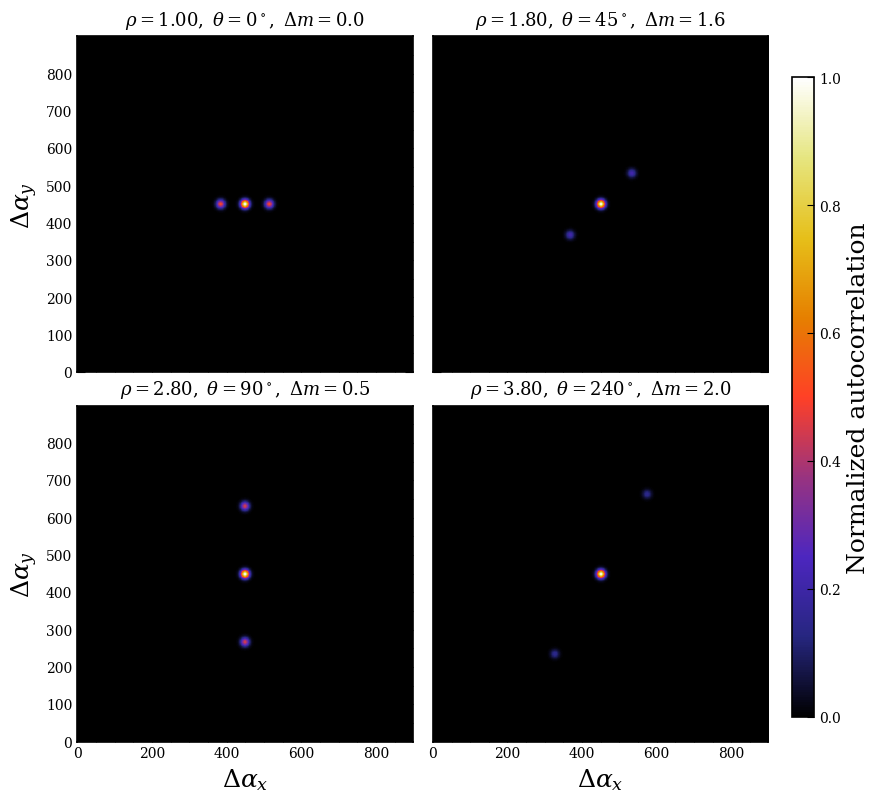

Saved: /content/binary_acf_clean.pdf


In [24]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['axes.linewidth'] = 1.2


def flux_ratio_from_deltam(delta_m):
    return 10 ** (-0.4 * delta_m)


def apply_axis_style(ax, xminor=50, yminor=50):
    ax.tick_params(axis='both', which='major', direction='in',
                   bottom=True, top=True, left=True, right=True, length=6)
    ax.tick_params(axis='both', which='minor', direction='in',
                   bottom=True, top=True, left=True, right=True, length=3)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(MultipleLocator(xminor))
    ax.yaxis.set_minor_locator(MultipleLocator(yminor))


def gaussian_2d(x, y, x0, y0, sigma, amp=1.0):
    return amp * np.exp(-((x - x0)**2 + (y - y0)**2) / (2.0 * sigma**2))


def illustrative_binary_acf(nx=900, ny=900, rho=1.0, theta_deg=0.0, delta_m=0.0,
                            sigma=7.0, rho_scale=120.0):
    # Illustrative autocorrelation: central peak plus symmetric secondary peaks
    y, x = np.mgrid[0:ny, 0:nx]
    xc = (nx - 1) / 2.0
    yc = (ny - 1) / 2.0

    r = flux_ratio_from_deltam(delta_m)

    a0 = 1.0 + r**2
    a1 = r

    theta = np.deg2rad(theta_deg)
    dx = rho_scale * rho * np.cos(theta)
    dy = rho_scale * rho * np.sin(theta)

    acf = np.zeros((ny, nx), dtype=float)

    acf += gaussian_2d(x, y, xc, yc, sigma=sigma, amp=a0)
    acf += gaussian_2d(x, y, xc + dx, yc + dy, sigma=sigma, amp=a1)
    acf += gaussian_2d(x, y, xc - dx, yc - dy, sigma=sigma, amp=a1)

    acf /= np.max(acf)

    return acf


def plot_binary_acf_group(savepath='/content/binary_acf_clean.pdf', cmap='CMRmap'):
    configs = [
        {"rho": 1.00, "theta": 0.0,   "dm": 0.0},
        {"rho": 1.80, "theta": 45.0,  "dm": 1.6},
        {"rho": 2.80, "theta": 90.0,  "dm": 0.5},
        {"rho": 3.80, "theta": 240.0, "dm": 2.0},
    ]

    fig, axes = plt.subplots(2, 2, figsize=(8.8, 8.2), sharex=True, sharey=True)
    axes = axes.ravel()

    last_im = None

    for ax, cfg, plabel in zip(axes, configs, ['(a)', '(b)', '(c)', '(d)']):
        acf = illustrative_binary_acf(
            nx=900, ny=900,
            rho=cfg["rho"],
            theta_deg=cfg["theta"],
            delta_m=cfg["dm"],
            sigma=8.0,
            rho_scale=65.0
        )

        last_im = ax.imshow(acf, origin='lower', cmap=cmap, vmin=0.0, vmax=1.0,
                            interpolation='nearest', aspect='equal')

        ax.annotate(plabel, xy=(0.84, 0.89), xycoords='axes fraction',
                    fontsize=22, color='black')

        ax.set_title(
            fr'$\rho={cfg["rho"]:.2f},\ \theta={cfg["theta"]:.0f}^\circ,\ \Delta m={cfg["dm"]:.1f}$',
            fontsize=13, color='black', pad=8
        )

        apply_axis_style(ax, xminor=50, yminor=50)

    axes[2].set_xlabel(r'$\Delta \alpha_x$', fontsize=18, family='serif')
    axes[3].set_xlabel(r'$\Delta \alpha_x$', fontsize=18, family='serif')
    axes[0].set_ylabel(r'$\Delta \alpha_y$', fontsize=18, family='serif')
    axes[2].set_ylabel(r'$\Delta \alpha_y$', fontsize=18, family='serif')

    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.08, top=0.94,
                        wspace=0.02, hspace=0.10)

    cax = fig.add_axes([0.90, 0.11, 0.025, 0.78])
    cbar = fig.colorbar(last_im, cax=cax)
    cbar.set_label('Normalized autocorrelation', fontsize=18, family='serif')
    cbar.ax.tick_params(direction='in', length=5)

    plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Saved: {savepath}')


plot_binary_acf_group()

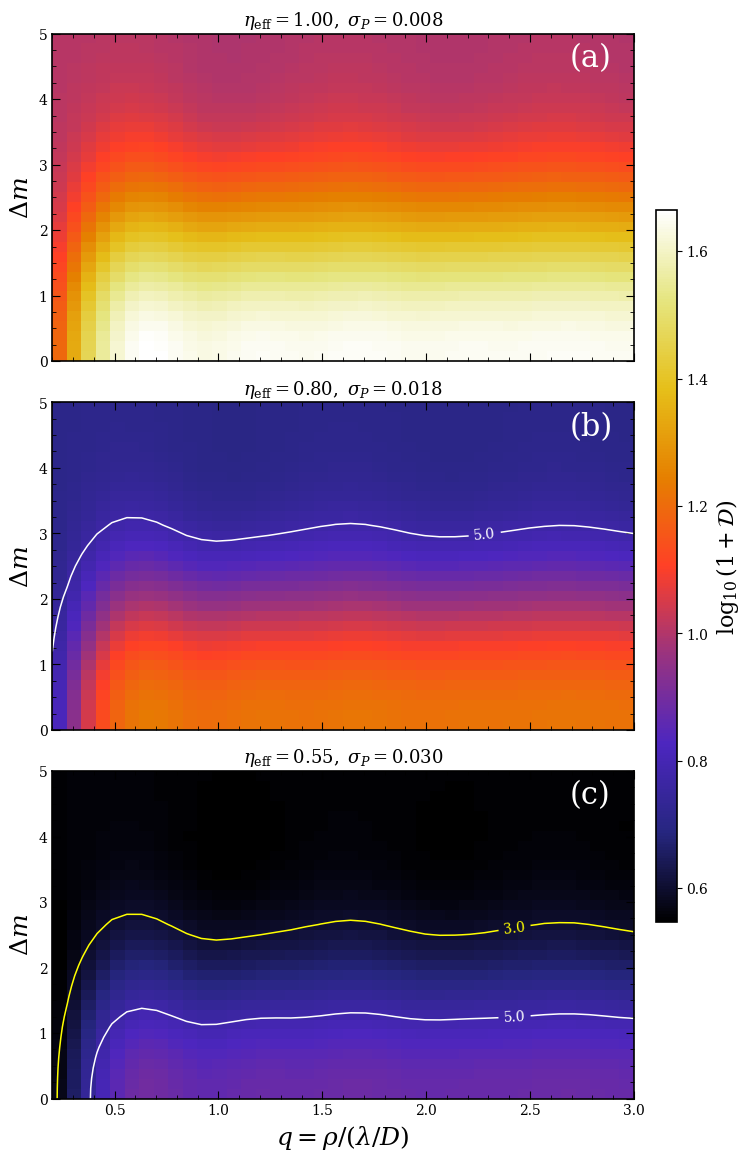

Guardado en: /content/sim1_detectability_three_maps.pdf
Existe archivo: True


In [2]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['axes.linewidth'] = 1.2


def flux_ratio_from_deltam(delta_m):
    return 10 ** (-0.4 * delta_m)


def binary_visibility_squared_2d(fx, fy, rho, theta_deg, r, eta=1.0):
    theta = np.deg2rad(theta_deg)
    rho_x = rho * np.cos(theta)
    rho_y = rho * np.sin(theta)
    phase = 2.0 * np.pi * (fx * rho_x + fy * rho_y)
    return (1.0 + r**2 + 2.0 * r * eta * np.cos(phase)) / (1.0 + r)**2


def smooth_binary_background(r):
    return (1.0 + r**2) / (1.0 + r)**2


def make_frequency_grid(fmax=1.0, n=256):
    f = np.linspace(-fmax, fmax, n)
    fx, fy = np.meshgrid(f, f)
    return fx, fy


def circular_support(fx, fy, fc=1.0, soft_edge=0.03):
    fr = np.sqrt(fx**2 + fy**2)
    width = soft_edge * fc
    support = 0.5 * (1.0 - np.tanh((fr - fc) / width))
    return support


def simulate_pws(q, delta_m, theta_deg=0.0, eta=1.0,
                 noise_sigma=0.01, ngrid=256, fmax=1.05,
                 fc=1.0, soft_edge=0.03, seed=None):
    # Generate a synthetic binary power spectrum
    rng = np.random.default_rng(seed)

    fx, fy = make_frequency_grid(fmax=fmax, n=ngrid)
    support = circular_support(fx, fy, fc=fc, soft_edge=soft_edge)

    r = flux_ratio_from_deltam(delta_m)
    rho = q

    pws = binary_visibility_squared_2d(fx, fy, rho=rho, theta_deg=theta_deg, r=r, eta=eta)
    pws = pws * support

    noise = rng.normal(0.0, noise_sigma, size=pws.shape)
    pws_noisy = pws + noise

    fr = np.sqrt(fx**2 + fy**2)
    mask = fr <= fc

    return fx, fy, pws_noisy, mask, r


def detectability_metric(pws, mask, r, noise_sigma):
    # Compute the modulation strength relative to the noise level
    p0 = smooth_binary_background(r)
    residual = pws[mask] - p0
    D = np.std(residual) / noise_sigma
    return D


def run_detectability_grid(q_values, delta_m_values,
                           theta_deg=0.0, eta=1.0, noise_sigma=0.01,
                           ngrid=256, fmax=1.05, fc=1.0, soft_edge=0.03,
                           n_realizations=10):
    D_map = np.zeros((len(delta_m_values), len(q_values)))

    for i, dm in enumerate(delta_m_values):
        for j, q in enumerate(q_values):
            D_vals = []

            for k in range(n_realizations):
                fx, fy, pws, mask, r = simulate_pws(
                    q=q,
                    delta_m=dm,
                    theta_deg=theta_deg,
                    eta=eta,
                    noise_sigma=noise_sigma,
                    ngrid=ngrid,
                    fmax=fmax,
                    fc=fc,
                    soft_edge=soft_edge,
                    seed=1000 + i * 100 + j * 10 + k
                )

                D = detectability_metric(pws, mask, r, noise_sigma)
                D_vals.append(D)

            D_map[i, j] = np.mean(D_vals)

    return D_map


def apply_axis_style(ax, xminor=None, yminor=None):
    ax.tick_params(axis='both', which='major', direction='in',
                   bottom=True, top=True, left=True, right=True, length=6)
    ax.tick_params(axis='both', which='minor', direction='in',
                   bottom=True, top=True, left=True, right=True, length=3)
    ax.minorticks_on()

    if xminor is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(xminor))
    if yminor is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(yminor))


def plot_detectability_three_maps(q_values, delta_m_values, D_maps, configs,
                                  savepath='/content/sim1_detectability_three_maps.pdf'):
    fig, axes = plt.subplots(3, 1, figsize=(7.4, 11.5), sharex=True, constrained_layout=True)

    extent = [q_values.min(), q_values.max(), delta_m_values.min(), delta_m_values.max()]
    Q, DM = np.meshgrid(q_values, delta_m_values)

    labels = ['(a)', '(b)', '(c)']
    ims = []

    # Use the same color scale for all panels
    all_logD = [np.log10(1.0 + D) for D in D_maps]
    vmin = min(np.nanmin(x) for x in all_logD)
    vmax = max(np.nanmax(x) for x in all_logD)

    for ax, D_map, cfg, lab in zip(axes, D_maps, configs, labels):
        logD = np.log10(1.0 + D_map)

        im = ax.imshow(
            logD,
            origin='lower',
            aspect='auto',
            extent=extent,
            cmap='CMRmap',
            interpolation='nearest',
            vmin=vmin,
            vmax=vmax
        )
        ims.append(im)

        # Draw contours on the original detectability metric
        cs = ax.contour(
            Q, DM, D_map,
            levels=[1.5, 3.0, 5.0],
            colors=['cyan', 'yellow', 'white'],
            linewidths=1.1
        )
        ax.clabel(cs, inline=True, fontsize=10, fmt='%.1f')

        ax.set_ylabel(r'$\Delta m$', fontsize=18, family='serif')
        ax.annotate(lab, xy=(0.89, 0.90), xycoords='axes fraction',
                    fontsize=22, color='white')

        ax.set_title(
            fr'$\eta_{{\rm eff}}={cfg["eta"]:.2f},\ \sigma_P={cfg["noise_sigma"]:.3f}$',
            fontsize=13, family='serif', pad=6
        )

        apply_axis_style(ax, xminor=0.1, yminor=0.25)

    axes[-1].set_xlabel(r'$q=\rho/(\lambda/D)$', fontsize=18, family='serif')

    cbar = fig.colorbar(ims[-1], ax=axes, pad=0.02, fraction=0.035, aspect=35)
    cbar.set_label(r'$\log_{10}(1+\mathcal{D})$', fontsize=16, family='serif')

    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Saved to: {savepath}')
    print(f'File exists: {os.path.exists(savepath)}')


q_values = np.linspace(0.2, 3.0, 40)
delta_m_values = np.linspace(0.0, 5.0, 33)

configs = [
    {"eta": 1.00, "noise_sigma": 0.008},
    {"eta": 0.80, "noise_sigma": 0.018},
    {"eta": 0.55, "noise_sigma": 0.030},
]

D_maps = []
for cfg in configs:
    D_map = run_detectability_grid(
        q_values=q_values,
        delta_m_values=delta_m_values,
        theta_deg=0.0,
        eta=cfg["eta"],
        noise_sigma=cfg["noise_sigma"],
        ngrid=256,
        fmax=1.05,
        fc=1.0,
        soft_edge=0.03,
        n_realizations=10
    )
    D_maps.append(D_map)

plot_detectability_three_maps(
    q_values=q_values,
    delta_m_values=delta_m_values,
    D_maps=D_maps,
    configs=configs,
    savepath='/content/sim1_detectability_three_maps.pdf'
)

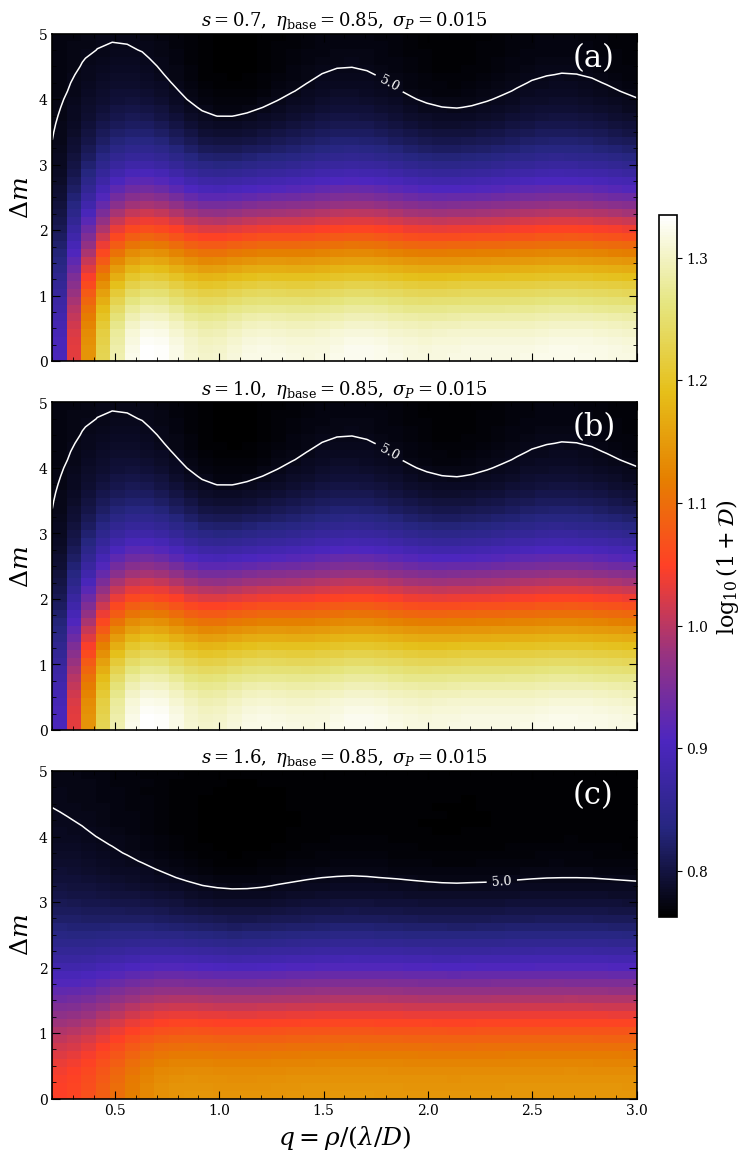

Guardado en: /content/sim2_sampling_three_maps.pdf
Existe archivo: True


In [3]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['axes.linewidth'] = 1.2


def flux_ratio_from_deltam(delta_m):
    return 10 ** (-0.4 * delta_m)


def binary_visibility_squared_2d(fx, fy, rho, theta_deg, r, eta=1.0):
    theta = np.deg2rad(theta_deg)
    rho_x = rho * np.cos(theta)
    rho_y = rho * np.sin(theta)
    phase = 2.0 * np.pi * (fx * rho_x + fy * rho_y)
    return (1.0 + r**2 + 2.0 * r * eta * np.cos(phase)) / (1.0 + r)**2


def smooth_binary_background(r):
    return (1.0 + r**2) / (1.0 + r)**2


def make_frequency_grid(fmax=1.0, n=256):
    f = np.linspace(-fmax, fmax, n)
    fx, fy = np.meshgrid(f, f)
    return fx, fy


def circular_support(fx, fy, fc=1.0, soft_edge=0.03):
    fr = np.sqrt(fx**2 + fy**2)
    width = soft_edge * fc
    support = 0.5 * (1.0 - np.tanh((fr - fc) / width))
    return support


def sampling_attenuation(fx, fy, s, fc=1.0, m=4):
    # Semi-analytical sampling attenuation model
    fr = np.sqrt(fx**2 + fy**2)

    if s <= 1.0:
        alpha = 0.0
    else:
        alpha = 4.0 * (s - 1.0)

    eta_samp = np.exp(-alpha * (fr / fc)**m)
    return eta_samp


def simulate_pws_sampling(q, delta_m, s,
                          theta_deg=0.0,
                          eta_base=0.85,
                          noise_sigma=0.015,
                          ngrid=256,
                          fmax=1.05,
                          fc=1.0,
                          soft_edge=0.03,
                          seed=None):
    # Generate a synthetic power spectrum including sampling attenuation
    rng = np.random.default_rng(seed)

    fx, fy = make_frequency_grid(fmax=fmax, n=ngrid)
    support = circular_support(fx, fy, fc=fc, soft_edge=soft_edge)
    eta_samp = sampling_attenuation(fx, fy, s=s, fc=fc, m=4)

    r = flux_ratio_from_deltam(delta_m)
    rho = q
    eta_eff = eta_base * eta_samp

    pws = binary_visibility_squared_2d(
        fx, fy,
        rho=rho,
        theta_deg=theta_deg,
        r=r,
        eta=1.0
    )

    p0 = smooth_binary_background(r)
    modulated = pws - p0
    pws_eff = p0 + eta_eff * modulated
    pws_eff = pws_eff * support

    noise = rng.normal(0.0, noise_sigma, size=pws_eff.shape)
    pws_noisy = pws_eff + noise

    fr = np.sqrt(fx**2 + fy**2)
    mask = fr <= fc

    return fx, fy, pws_noisy, mask, r


def detectability_metric(pws, mask, r, noise_sigma):
    # Compute the modulation strength relative to the noise level
    p0 = smooth_binary_background(r)
    residual = pws[mask] - p0
    D = np.std(residual) / noise_sigma
    return D


def run_detectability_grid_sampling(q_values, delta_m_values, s,
                                    theta_deg=0.0,
                                    eta_base=0.85,
                                    noise_sigma=0.015,
                                    ngrid=256,
                                    fmax=1.05,
                                    fc=1.0,
                                    soft_edge=0.03,
                                    n_realizations=10):
    D_map = np.zeros((len(delta_m_values), len(q_values)))

    for i, dm in enumerate(delta_m_values):
        for j, q in enumerate(q_values):
            D_vals = []

            for k in range(n_realizations):
                fx, fy, pws, mask, r = simulate_pws_sampling(
                    q=q,
                    delta_m=dm,
                    s=s,
                    theta_deg=theta_deg,
                    eta_base=eta_base,
                    noise_sigma=noise_sigma,
                    ngrid=ngrid,
                    fmax=fmax,
                    fc=fc,
                    soft_edge=soft_edge,
                    seed=2000 + i * 100 + j * 10 + k
                )

                D = detectability_metric(pws, mask, r, noise_sigma)
                D_vals.append(D)

            D_map[i, j] = np.mean(D_vals)

    return D_map


def apply_axis_style(ax, xminor=None, yminor=None):
    ax.tick_params(axis='both', which='major', direction='in',
                   bottom=True, top=True, left=True, right=True, length=6)
    ax.tick_params(axis='both', which='minor', direction='in',
                   bottom=True, top=True, left=True, right=True, length=3)
    ax.minorticks_on()

    if xminor is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(xminor))
    if yminor is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(yminor))


def plot_sampling_three_maps(q_values, delta_m_values, D_maps, s_values,
                             eta_base=0.85, noise_sigma=0.015,
                             savepath='/content/sim2_sampling_three_maps.pdf'):
    fig, axes = plt.subplots(3, 1, figsize=(7.4, 11.5), sharex=True, constrained_layout=True)

    extent = [q_values.min(), q_values.max(), delta_m_values.min(), delta_m_values.max()]
    Q, DM = np.meshgrid(q_values, delta_m_values)

    labels = ['(a)', '(b)', '(c)']
    ims = []

    # Use the same color scale for all panels
    all_logD = [np.log10(1.0 + D) for D in D_maps]
    vmin = min(np.nanmin(x) for x in all_logD)
    vmax = max(np.nanmax(x) for x in all_logD)

    for ax, D_map, s, lab in zip(axes, D_maps, s_values, labels):
        logD = np.log10(1.0 + D_map)

        im = ax.imshow(
            logD,
            origin='lower',
            aspect='auto',
            extent=extent,
            cmap='CMRmap',
            interpolation='nearest',
            vmin=vmin,
            vmax=vmax
        )
        ims.append(im)

        # Draw contours on the original detectability metric
        cs = ax.contour(
            Q, DM, D_map,
            levels=[1.5, 3.0, 5.0],
            colors=['cyan', 'yellow', 'white'],
            linewidths=1.1
        )
        ax.clabel(cs, inline=True, fontsize=9, fmt='%.1f')

        ax.set_ylabel(r'$\Delta m$', fontsize=18, family='serif')
        ax.annotate(lab, xy=(0.89, 0.90), xycoords='axes fraction',
                    fontsize=22, color='white')

        ax.set_title(
            fr'$s={s:.1f},\ \eta_{{\rm base}}={eta_base:.2f},\ \sigma_P={noise_sigma:.3f}$',
            fontsize=13, family='serif', pad=6
        )

        apply_axis_style(ax, xminor=0.1, yminor=0.25)

    axes[-1].set_xlabel(r'$q=\rho/(\lambda/D)$', fontsize=18, family='serif')

    cbar = fig.colorbar(ims[-1], ax=axes, pad=0.02, fraction=0.03, aspect=40)
    cbar.set_label(r'$\log_{10}(1+\mathcal{D})$', fontsize=16, family='serif')

    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Saved to: {savepath}')
    print(f'File exists: {os.path.exists(savepath)}')


q_values = np.linspace(0.2, 3.0, 40)
delta_m_values = np.linspace(0.0, 5.0, 41)

s_values = [0.7, 1.0, 1.6]

D_maps = []
for s in s_values:
    D_map = run_detectability_grid_sampling(
        q_values=q_values,
        delta_m_values=delta_m_values,
        s=s,
        theta_deg=0.0,
        eta_base=0.85,
        noise_sigma=0.015,
        ngrid=256,
        fmax=1.05,
        fc=1.0,
        soft_edge=0.03,
        n_realizations=10
    )
    D_maps.append(D_map)

plot_sampling_three_maps(
    q_values=q_values,
    delta_m_values=delta_m_values,
    D_maps=D_maps,
    s_values=s_values,
    eta_base=0.85,
    noise_sigma=0.015,
    savepath='/content/sim2_sampling_three_maps.pdf'
)

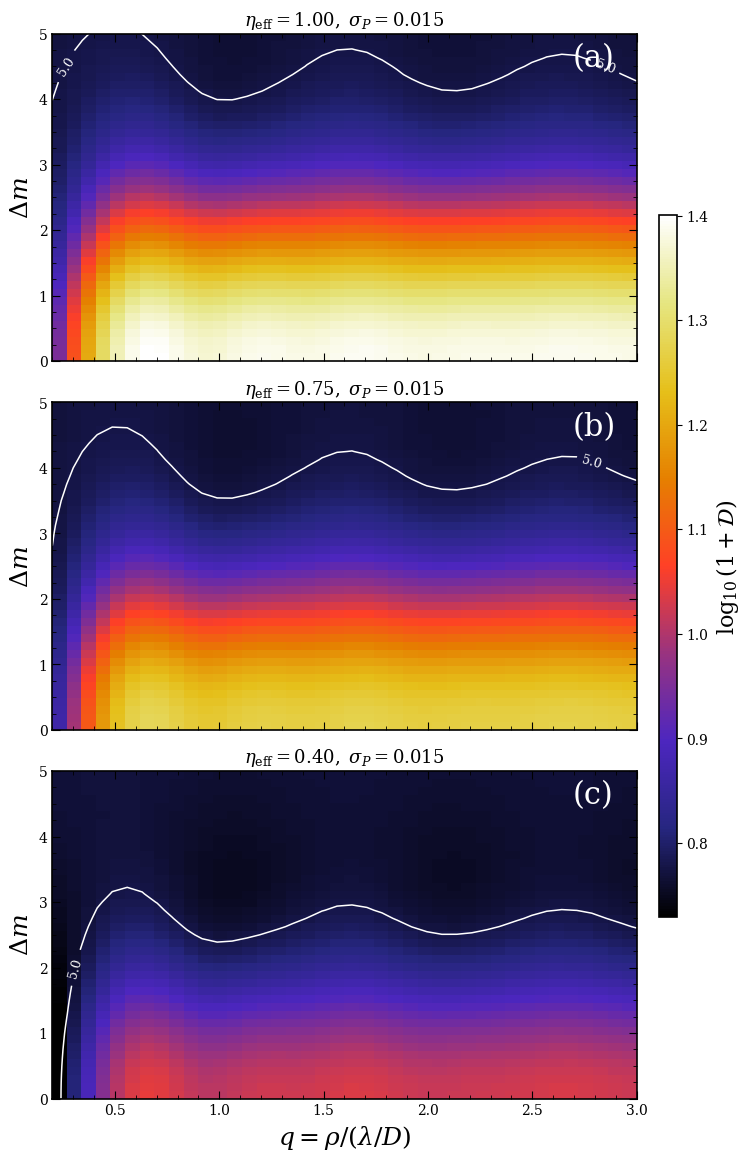

Saved to: /content/sim3_eta_three_maps.pdf
File exists: True


In [25]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['axes.linewidth'] = 1.2


def flux_ratio_from_deltam(delta_m):
    return 10 ** (-0.4 * delta_m)


def binary_visibility_squared_2d(fx, fy, rho, theta_deg, r, eta=1.0):
    theta = np.deg2rad(theta_deg)
    rho_x = rho * np.cos(theta)
    rho_y = rho * np.sin(theta)
    phase = 2.0 * np.pi * (fx * rho_x + fy * rho_y)
    return (1.0 + r**2 + 2.0 * r * eta * np.cos(phase)) / (1.0 + r)**2


def smooth_binary_background(r):
    return (1.0 + r**2) / (1.0 + r)**2


def make_frequency_grid(fmax=1.0, n=256):
    f = np.linspace(-fmax, fmax, n)
    fx, fy = np.meshgrid(f, f)
    return fx, fy


def circular_support(fx, fy, fc=1.0, soft_edge=0.03):
    fr = np.sqrt(fx**2 + fy**2)
    width = soft_edge * fc
    support = 0.5 * (1.0 - np.tanh((fr - fc) / width))
    return support


def simulate_pws_eta(q, delta_m, eta_eff,
                     theta_deg=0.0,
                     noise_sigma=0.015,
                     ngrid=256,
                     fmax=1.05,
                     fc=1.0,
                     soft_edge=0.03,
                     seed=None):
    # Generate a synthetic power spectrum with global modulation attenuation
    rng = np.random.default_rng(seed)

    fx, fy = make_frequency_grid(fmax=fmax, n=ngrid)
    support = circular_support(fx, fy, fc=fc, soft_edge=soft_edge)

    r = flux_ratio_from_deltam(delta_m)
    rho = q

    pws = binary_visibility_squared_2d(
        fx, fy,
        rho=rho,
        theta_deg=theta_deg,
        r=r,
        eta=1.0
    )

    p0 = smooth_binary_background(r)
    modulated = pws - p0
    pws_eff = p0 + eta_eff * modulated
    pws_eff = pws_eff * support

    noise = rng.normal(0.0, noise_sigma, size=pws_eff.shape)
    pws_noisy = pws_eff + noise

    fr = np.sqrt(fx**2 + fy**2)
    mask = fr <= fc

    return fx, fy, pws_noisy, mask, r


def detectability_metric(pws, mask, r, noise_sigma):
    # Compute the modulation strength relative to the noise level
    p0 = smooth_binary_background(r)
    residual = pws[mask] - p0
    D = np.std(residual) / noise_sigma
    return D


def run_detectability_grid_eta(q_values, delta_m_values, eta_eff,
                               theta_deg=0.0,
                               noise_sigma=0.015,
                               ngrid=256,
                               fmax=1.05,
                               fc=1.0,
                               soft_edge=0.03,
                               n_realizations=10):
    D_map = np.zeros((len(delta_m_values), len(q_values)))

    for i, dm in enumerate(delta_m_values):
        for j, q in enumerate(q_values):
            D_vals = []

            for k in range(n_realizations):
                fx, fy, pws, mask, r = simulate_pws_eta(
                    q=q,
                    delta_m=dm,
                    eta_eff=eta_eff,
                    theta_deg=theta_deg,
                    noise_sigma=noise_sigma,
                    ngrid=ngrid,
                    fmax=fmax,
                    fc=fc,
                    soft_edge=soft_edge,
                    seed=3000 + i * 100 + j * 10 + k
                )

                D = detectability_metric(pws, mask, r, noise_sigma)
                D_vals.append(D)

            D_map[i, j] = np.mean(D_vals)

    return D_map


def apply_axis_style(ax, xminor=None, yminor=None):
    ax.tick_params(axis='both', which='major', direction='in',
                   bottom=True, top=True, left=True, right=True, length=6)
    ax.tick_params(axis='both', which='minor', direction='in',
                   bottom=True, top=True, left=True, right=True, length=3)
    ax.minorticks_on()

    if xminor is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(xminor))
    if yminor is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(yminor))


def plot_eta_three_maps(q_values, delta_m_values, D_maps, eta_values,
                        noise_sigma=0.015,
                        savepath='/content/sim5_eta_three_maps.pdf'):
    fig, axes = plt.subplots(3, 1, figsize=(7.4, 11.5), sharex=True, constrained_layout=True)

    extent = [q_values.min(), q_values.max(), delta_m_values.min(), delta_m_values.max()]
    Q, DM = np.meshgrid(q_values, delta_m_values)

    labels = ['(a)', '(b)', '(c)']
    ims = []

    # Use the same color scale for all panels
    all_logD = [np.log10(1.0 + D) for D in D_maps]
    vmin = min(np.nanmin(x) for x in all_logD)
    vmax = max(np.nanmax(x) for x in all_logD)

    for ax, D_map, eta_eff, lab in zip(axes, D_maps, eta_values, labels):
        logD = np.log10(1.0 + D_map)

        im = ax.imshow(
            logD,
            origin='lower',
            aspect='auto',
            extent=extent,
            cmap='CMRmap',
            interpolation='nearest',
            vmin=vmin,
            vmax=vmax
        )
        ims.append(im)

        # Draw contours on the original detectability metric
        cs = ax.contour(
            Q, DM, D_map,
            levels=[1.5, 3.0, 5.0],
            colors=['cyan', 'yellow', 'white'],
            linewidths=1.1
        )
        ax.clabel(cs, inline=True, fontsize=9, fmt='%.1f')

        ax.set_ylabel(r'$\Delta m$', fontsize=18, family='serif')
        ax.annotate(lab, xy=(0.89, 0.90), xycoords='axes fraction',
                    fontsize=22, color='white')

        ax.set_title(
            fr'$\eta_{{\rm eff}}={eta_eff:.2f},\ \sigma_P={noise_sigma:.3f}$',
            fontsize=13, family='serif', pad=6
        )

        apply_axis_style(ax, xminor=0.1, yminor=0.25)

    axes[-1].set_xlabel(r'$q=\rho/(\lambda/D)$', fontsize=18, family='serif')

    cbar = fig.colorbar(ims[-1], ax=axes, pad=0.02, fraction=0.03, aspect=40)
    cbar.set_label(r'$\log_{10}(1+\mathcal{D})$', fontsize=16, family='serif')

    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Saved to: {savepath}')
    print(f'File exists: {os.path.exists(savepath)}')


q_values = np.linspace(0.2, 3.0, 40)
delta_m_values = np.linspace(0.0, 5.0, 41)

eta_values = [1.00, 0.75, 0.40]

D_maps = []
for eta_eff in eta_values:
    D_map = run_detectability_grid_eta(
        q_values=q_values,
        delta_m_values=delta_m_values,
        eta_eff=eta_eff,
        theta_deg=0.0,
        noise_sigma=0.015,
        ngrid=256,
        fmax=1.05,
        fc=1.0,
        soft_edge=0.03,
        n_realizations=10
    )
    D_maps.append(D_map)

plot_eta_three_maps(
    q_values=q_values,
    delta_m_values=delta_m_values,
    D_maps=D_maps,
    eta_values=eta_values,
    noise_sigma=0.015,
    savepath='/content/sim3_eta_three_maps.pdf'
)